# Week 2 — Financial Data and Returns

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/02/week2_main.ipynb)

The repository is currently private. The direct Colab link requires permission to the repository and GitHub authorization in Colab. If the link does not open, download `week2_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 2 lesson. It integrates preparation, financial concepts, executable examples, output interpretation, discussion questions, evidence checks, independent practice, troubleshooting, extensions, and sources in one document.

## Core financial question

What must be known, checked, and calculated before a table of financial prices can support a valid return calculation?

Week 1 introduced the course workflow. Week 2 establishes the financial-data and return foundation for that workflow. Week 3 will ask when a variable became available, calculate technical indicators and financially motivated features, and convert a stated feature rule into a signal. Week 2 stops before those questions: it does not build a trading signal, fit a prediction model, or report backtest performance.

The sequence stops before technical indicators, trading signals, prediction models, and backtesting. All required calculations use fixed artificial data. Issue 2 contains an optional live yfinance query so that students can examine a real retrieval process without making the rest of the lesson depend on internet access.

Run the notebook from top to bottom. Keep every prediction, output, revision, and unresolved question. A successful execution confirms only that the documented calculations ran in the stated environment; it does not validate a real provider or establish investment value.

## Observable outcome

After completing Week 2, you will produce an audited financial-data record and a reproducible return notebook. The evidence will identify the asset, market, fields, units, currency, timestamps, observation frequency, corporate-action assumptions, data problems, return definitions, frequency conversion, and common holding intervals. It will include simple and log returns, compounded returns, a wealth index, and one-period fixed-weight portfolio returns.

All numerical data in this lesson are artificial. They support calculation and auditing practice only. They do not describe a real security, document a real provider, or support an investment recommendation.

## Learning objectives

After completing Week 2, you should be able to:

- identify what a financial-data row and field claim to measure;
- distinguish raw, closing, adjusted, and total-return information without assuming that provider labels are universal;
- calculate and reconcile simple returns, log returns, compounded returns, geometric mean returns, and a wealth index;
- audit asset identity, units, currency, timestamps, duplicates, missing values, invalid values, trading-calendar assumptions, and observation frequency;
- align multiple assets over common holding intervals and calculate a one-period fixed-weight portfolio return; and
- preserve reproducible evidence while limiting conclusions to the data and assumptions actually checked.

## Before you begin

Use a browser-based or local Python notebook with `numpy`, `pandas`, and `matplotlib`. The optional live example also uses `yfinance`. If the environment is not ready, follow the preparation section below or run the [environment and data check](../resources/notebooks/00_Colab_課前環境與資料檢查.ipynb). A real data source, asset universe, and period have not yet been approved for the course.

The twenty issues are connected. A field decision changes the return definition; a date or unit error changes the holding interval; and an invalid holding interval makes a portfolio calculation uninterpretable even when the arithmetic is correct.

Each issue follows the same learning sequence: read the financial problem, write a prediction, execute the example, interpret the visible output, discuss four questions, preserve the requested evidence, and use the stated first diagnostic action when the result is unexpected.

# Navigation through the twenty issues

The twenty issues form five connected sections. The table below shows what each section establishes and why the next section depends on it. All twenty issues remain part of the complete Week 2 material.

| Section | Issues | Main question | Evidence carried forward |
|---|---:|---|---|
| Financial-data meaning and provenance | 1–3 | What does the value represent, where did it come from, and which asset does it describe? | Documented rows, retrieval record, and asset identity |
| Fields, corporate actions, and units | 4–8 | Which field and convention answer the financial question without double counting or unit errors? | Selected price or return field, corporate-action assumptions, and consistent units |
| Return calculation and compounding | 9–14 | How are simple return, log return, compounded return, wealth, and average return calculated and reconciled? | Verified return identities, wealth path, and stated interpretation |
| Data integrity, calendars, and time | 15–18 | Are dates, values, sessions, timestamps, and observation frequencies valid for the intended interval? | Audited rows, unresolved data decisions, and explicit interval boundaries |
| Multi-asset calculation | 19–20 | Do the component returns share one holding interval, and how do fixed starting weights combine them? | Common endpoint table, component returns, weights, contributions, and portfolio return |

The notebook introduces return formulas before the complete data-and-time audit so that each calculation can be examined separately. In an actual analysis, however, apply the dependency in this order:

```text
meaning and source
        ↓
field, event, and unit conventions
        ↓
data and time validation
        ↓
return calculation and compounding
        ↓
same-interval multi-asset calculation
```

A later calculation cannot repair an earlier ambiguity. If asset identity, field meaning, units, or interval boundaries remain unresolved, return to the relevant earlier section before interpreting the result.

## Working rules

- Use decimal returns in calculations. Convert to percentages only for communication.
- Treat every asset, market, currency, and value labeled artificial as an invented teaching example.
- Do not silently repair a value. Preserve the original, explain the problem, and state the rule used to create any revised version.
- A provider label is not a definition. Real-data work requires the provider documentation and retrieval record.
- Do not include downloaded Yahoo Finance rows or notebook output containing those rows in the course repository unless their permitted use and redistribution have been verified.

# Preparation and required records

## Before class

Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, and `matplotlib`. The optional source-and-retrieval example imports `yfinance`, but all required calculations remain executable without a live download. If needed, run the [environment and data check](../resources/notebooks/00_Colab_課前環境與資料檢查.ipynb).

Run this notebook from top to bottom. Preserve predictions before each example, visible outputs, revisions, discussion responses, and the requested evidence. Do not include downloaded Yahoo Finance rows or saved notebook output containing those rows in a course submission or repository unless their permitted use and redistribution have been verified.

The preparation notebook uses fixed artificial data and does not download market data. Before class, confirm that you can:

- create and run a notebook from its first cell to its last cell;
- import `numpy`, `pandas`, and `matplotlib`;
- display a `DataFrame` and its `dtypes`;
- save or export the notebook with visible outputs; and
- preserve the complete error message if an environment check fails.

The common market, assets, period, provider fields, currency, and redistribution conditions remain pending. Do not substitute an online dataset into required Week 2 work unless the instructor publishes those decisions.

## Data-processing record

Complete this record with facts visible in the source or notebook. Use `pending` when a required fact is not yet known. Do not write `none` unless the item was checked and none was found.

```text
Provider and dataset:
Retrieval date and query or file identifier:
Redistribution status:
Artificial or real:
Asset identifier:
Asset name and security type:
Market or venue:
Currency and price unit:
Date range:
Timestamp meaning and time zone:
Observation frequency:
OHLCV session definition:
Price or return field selected:
Provider definition of that field:
Corporate actions and distributions included:
Return formulas and reporting units:
Date parsing and sorting rule:
Duplicate result and action:
Missing-value result and action:
Invalid or extreme-value result and action:
Trading-calendar evidence:
Frequency-conversion rule by field:
Multi-asset alignment rule:
Portfolio-weight assumption:
Automated checks executed:
Files and outputs preserved:
Claim supported by this evidence:
Claim not supported by this evidence:
Unresolved questions:
```

## Data dictionary for the artificial examples

The descriptions below apply only to the artificial examples in this notebook. A real provider's documentation replaces them when real data are approved.

| Field or role | Meaning in the artificial examples | Required check |
|---|---|---|
| `Date` or `Timestamp` | Artificial date or time label under the convention stated in that issue | Parse explicitly; verify uniqueness and order; do not infer a real exchange or time zone |
| `Open` | First artificial price included in the session | Positive and between `Low` and `High` |
| `High` | Largest artificial included price | Positive and not below `Open`, `Close`, or `Low` |
| `Low` | Smallest artificial included price | Positive and not above `Open`, `Close`, or `High` |
| `Close` | Final artificial included price | Positive and between `Low` and `High` |
| `Volume` | Artificial number of traded units included in the session | Nonnegative; unit must be documented before real-data use |
| Issue-specific price series | Artificial price selected for the calculation in that issue | Positive, nonmissing for the required interval, consistently defined, and sorted before returns are calculated |
| `Shares` | Artificial number of shares used in a split or position-value example | Positive and interpreted with the stated event convention |
| `Cash_distribution` | Artificial cash amount included under the stated holding-period convention | Do not add it to a provider-adjusted or total-return field a second time |
| Asset-labelled columns | Artificial price series for different assets | Verify asset identity and align common start and end boundaries before combining returns |

The examples do not use one shared real dataset. The split and cash-distribution calculations in Issues 6–7 and Practice issue 1 are separate artificial cases. Do not apply their event assumptions to another issue unless that issue states them.

## Required audit checks

Preserve the output of every applicable check. A passed assertion does not replace the source record or financial interpretation.

### Identity and metadata

- Each asset has an identifier, name or artificial label, security type, market, and currency entry.
- Provider, dataset, retrieval information, and redistribution status are present.
- Every field has a definition and unit.
- Artificial labels are not presented as real assets or markets.

### Dates and intervals

- Dates parse under an explicit format.
- The index is unique and sorted before returns are calculated.
- Timestamp meaning and time zone are recorded or explicitly pending.
- Calendar gaps are classified using market evidence rather than weekday assumptions alone.
- Multi-asset returns share common start and end boundaries.

### Values and corporate actions

- Prices required by the Week 2 formulas are finite and positive.
- Volume is nonnegative and its unit is known or pending.
- OHLC range relations are checked.
- Missing, repeated, stale, or extreme values remain visible until a documented decision is made.
- Splits, dividends, and adjusted fields are not counted twice.

### Returns and aggregation

- The first return remains missing.
- Simple and log returns reconcile within numerical tolerance.
- Compounded simple return agrees with the endpoint ratio when the assumptions permit that identity.
- The geometric mean reproduces terminal wealth over the same nonmissing periods.
- Frequency conversion uses an aggregation appropriate to each field.
- Portfolio weights are finite, nonnegative, sum to one, and multiply same-interval asset returns.

In [1]:
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_AVAILABLE = False
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (7.2, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
        "yfinance_available": YFINANCE_AVAILABLE,
    },
    name="environment",
)
display(environment.rename_axis("Item").to_frame("Value"))

,Value
Item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0
yfinance_available,True


## Issue 1 — What does one financial-data row represent?


A row is an observation recorded under a convention. It is not automatically a trade, a complete market session, or a value that was publicly available at the timestamp shown. A number becomes interpretable only when the asset, market or venue, field, unit, currency, timestamp meaning, and frequency are known.

The example contrasts an ambiguous two-field record with a documented observation. The documented row is more useful, but its additional fields still do not prove that the value is correct. Metadata improve interpretation; source and validity checks remain necessary.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [2]:
record_a = {
    "Date": "2026-01-05",
    "Value": 100.0,
}

record_b = {
    "Asset": "Asset_A",
    "Market": "Artificial market",
    "Timestamp": "2026-01-05 16:00",
    "Timestamp_meaning": "Artificial session close",
    "Field": "Closing price",
    "Value": 100.0,
    "Unit": "Artificial currency units per share",
    "Currency": "ACU",
    "Frequency": "One observation per artificial session",
}

required_meaning = {
    "Asset",
    "Market",
    "Timestamp",
    "Timestamp_meaning",
    "Field",
    "Unit",
    "Currency",
    "Frequency",
}

comparison = pd.DataFrame(
    {
        "Record A": pd.Series(record_a),
        "Record B": pd.Series(record_b),
    }
)
display(comparison)

missing_a = sorted(required_meaning.difference(record_a))
missing_b = sorted(required_meaning.difference(record_b))
print("Missing meaning in Record A:", missing_a)
print("Missing meaning in Record B:", missing_b)

assert len(missing_a) == 8
assert missing_b == []

,Record A,Record B
Asset,NaN,Asset_A
Currency,NaN,ACU
Date,2026-01-05,NaN
Field,NaN,Closing price
Frequency,NaN,One observation per artificial session
Market,NaN,Artificial market
Timestamp,NaN,2026-01-05 16:00
Timestamp_meaning,NaN,Artificial session close
Unit,NaN,Artificial currency units per share
Value,100.0,100.0


Missing meaning in Record A: ['Asset', 'Currency', 'Field', 'Frequency', 'Market', 'Timestamp', 'Timestamp_meaning', 'Unit']
Missing meaning in Record B: []


### Interpret the output


Record A permits several incompatible interpretations of the number 100. Record B narrows the interpretation to one artificial closing-price observation. Notice that Record B still does not state a provider, retrieval date, or method used to verify the value.


### Discussion questions

1. Name three different financial quantities that the value 100 in Record A could represent.
2. Why does a date label alone fail to identify when information became available?
3. Which metadata describe economic meaning, and which metadata would instead support provenance?
4. Would Record B become a transaction record merely by adding a volume field? Explain.

### Evidence to preserve

Save both records, the two missing-field lists, your original prediction, and a revised one-sentence definition of a financial-data row.

### First diagnostic action

When a row remains ambiguous, list every missing field before calculating a return.

## Issue 2 — Which source and retrieval record support the data?


Reproducibility requires more than a URL. A retrieval record should identify the library or access method, provider, symbol, date range, interval, adjustment and corporate-action settings, package version, retrieval time, and any redistribution limitation that affects the submitted work.

yfinance is an open-source interface to Yahoo Finance data; it is not an official Yahoo product. Review the [yfinance project notice](https://github.com/ranaroussi/yfinance/blob/main/README.md) and the current [download-function documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) before using the query. If yfinance is unavailable in Colab, install it in a separate cell with %pip install yfinance and then rerun the environment cell.

The live query below is disabled by default. Students may enable it in a connected environment, inspect only a small result, and preserve the query record rather than including the downloaded rows in a course submission or repository. The fixed artificial examples in later issues do not depend on this query.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [3]:
query_record = pd.Series(
    {
        "access_library": "yfinance",
        "library_version": YFINANCE_VERSION,
        "provider_named_by_library": "Yahoo Finance",
        "symbol": "MSFT",
        "start": "2024-01-02",
        "end": "2024-02-01",
        "interval": "1d",
        "auto_adjust": False,
        "actions": True,
        "retrieval_time_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "raw_rows_permitted_in_course_submission": "not established by this notebook",
    },
    name="query_record",
)
display(query_record.rename_axis("Query setting").to_frame("Recorded value"))

RUN_LIVE_DOWNLOAD = False
live_download = None

if not RUN_LIVE_DOWNLOAD:
    print("Live download skipped. Set RUN_LIVE_DOWNLOAD = True in a connected class environment.")
elif not YFINANCE_AVAILABLE:
    print("Live download skipped because yfinance is not installed.")
else:
    try:
        live_download = yf.download(
            tickers=query_record["symbol"],
            start=query_record["start"],
            end=query_record["end"],
            interval=query_record["interval"],
            auto_adjust=query_record["auto_adjust"],
            actions=query_record["actions"],
            progress=False,
            threads=False,
            multi_level_index=False,
        )
        print("Downloaded shape:", live_download.shape)
        display(live_download.head(3))
        print("Columns:", list(live_download.columns))
    except Exception as exc:
        print("Live download failed; preserve this message and continue with artificial data.")
        print(type(exc).__name__, str(exc)[:300])

assert query_record["auto_adjust"] is False
assert query_record["actions"] is True

,Recorded value
Query setting,
access_library,yfinance
library_version,1.2.0
provider_named_by_library,Yahoo Finance
symbol,MSFT
start,2024-01-02
end,2024-02-01
interval,1d
auto_adjust,False
actions,True


Live download skipped. Set RUN_LIVE_DOWNLOAD = True in a connected class environment.


### Interpret the output


The query record is available even when the network call is skipped or fails. This separation is deliberate: a reproducible specification records what was requested, while the retrieval result records what the service returned at that time. Repeating the same query later may produce a different row set because providers can revise, correct, or reformat data.


### Discussion questions

1. What is the difference between yfinance as an access library and Yahoo Finance as the named data provider?
2. Why must auto_adjust and actions be recorded rather than left at undocumented defaults?
3. Which parts of the result might change if the same query is repeated next month?
4. What evidence should be submitted if the live request fails during class?

### Evidence to preserve

Save the query record, package version, live-query status, column names when available, and the exact failure message when unavailable. Do not save raw downloaded rows to the course repository unless permitted use and redistribution have been verified.

### First diagnostic action

When a retrieval is empty or fails, inspect the symbol, dates, interval, package version, network status, and complete error message before changing the financial question.

## Issue 3 — Have you identified the asset rather than only a short symbol?


A short symbol is convenient but incomplete. Symbols may be reused across venues, changed over time, or used for different security types. An asset record should preserve the provider identifier, descriptive name, security type, market or venue, trading currency, and the date range for which the mapping is intended.

The artificial asset master below contains one complete record, one incomplete record, and two rows that reuse the same short symbol on different venues. The duplicate symbol is not automatically an error; it is evidence that the symbol alone is not a unique key.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [4]:
asset_master = pd.DataFrame(
    [
        ["AAA", "Artificial Alpha", "Common stock", "Venue_X", "ACU", "2026-01-01", None],
        ["BBB", "Artificial Beta", None, "Venue_X", "ACU", "2026-01-01", None],
        ["XYZ", "Artificial X One", "Fund", "Venue_X", "ACU", "2026-01-01", None],
        ["XYZ", "Artificial X Two", "Common stock", "Venue_Y", "BCU", "2026-01-01", None],
    ],
    columns=[
        "Symbol",
        "Asset_name",
        "Security_type",
        "Venue",
        "Currency",
        "Mapping_start",
        "Mapping_end",
    ],
)

asset_master["Composite_key"] = (
    asset_master["Symbol"] + "|" + asset_master["Venue"] + "|" + asset_master["Currency"]
)

display(asset_master)
print("Duplicated short symbols:", asset_master["Symbol"].duplicated(keep=False).sum())
print("Duplicated composite keys:", asset_master["Composite_key"].duplicated().sum())
print("Missing security types:", asset_master["Security_type"].isna().sum())

assert asset_master["Symbol"].duplicated(keep=False).sum() == 2
assert asset_master["Composite_key"].is_unique
assert asset_master["Security_type"].isna().sum() == 1

,Symbol,Asset_name,Security_type,Venue,Currency,Mapping_start,Mapping_end,Composite_key
0,AAA,Artificial Alpha,Common stock,Venue_X,ACU,2026-01-01,None,AAA|Venue_X|ACU
1,BBB,Artificial Beta,None,Venue_X,ACU,2026-01-01,None,BBB|Venue_X|ACU
2,XYZ,Artificial X One,Fund,Venue_X,ACU,2026-01-01,None,XYZ|Venue_X|ACU
3,XYZ,Artificial X Two,Common stock,Venue_Y,BCU,2026-01-01,None,XYZ|Venue_Y|BCU


Duplicated short symbols: 2
Duplicated composite keys: 0
Missing security types: 1


### Interpret the output


The two XYZ rows show why a join based only on Symbol could attach prices to the wrong instrument. The incomplete BBB row should remain pending until security type is verified; filling it by analogy would create unsupported metadata.


### Discussion questions

1. Which columns are required to distinguish the two XYZ records?
2. How could a symbol change create a false price jump in a long historical file?
3. Why should an index level, fund price, futures settlement, and stock close not share one undocumented price definition?
4. When would a composite key still be insufficient to establish historical identity?

### Evidence to preserve

Save the asset master, duplicate-symbol count, composite-key check, missing-field count, and a sentence stating which field must remain pending.

### First diagnostic action

When two sources use the same symbol, compare provider identifiers, venue, currency, security type, and effective dates before joining.

## Issue 4 — What do Open, High, Low, Close, and Volume mean?


OHLCV fields summarize observations under a provider and session convention. Open and Close are the first and final included prices; High and Low are the largest and smallest included prices; Volume is a reported traded quantity under a stated unit. The words do not reveal whether extended sessions are included or whether volume counts shares, contracts, or another quantity.

Arithmetic range checks can detect contradictions, but they cannot verify the session definition. The example includes one intentionally invalid row whose High is below its Close.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Open,High,Low,Close,Volume
Date,,,,,
2026-01-05,100.0,103.0,99.5,102.0,1000000
2026-01-06,102.0,101.0,100.5,102.5,1100000
2026-01-07,101.0,102.0,100.0,101.5,950000


,low_not_above_open,low_not_above_close,high_not_below_open,high_not_below_close,volume_nonnegative,row_passes_arithmetic
Date,,,,,,
2026-01-05,True,True,True,True,True,True
2026-01-06,True,True,False,False,True,False
2026-01-07,True,True,True,True,True,True


Rows failing arithmetic checks: 1


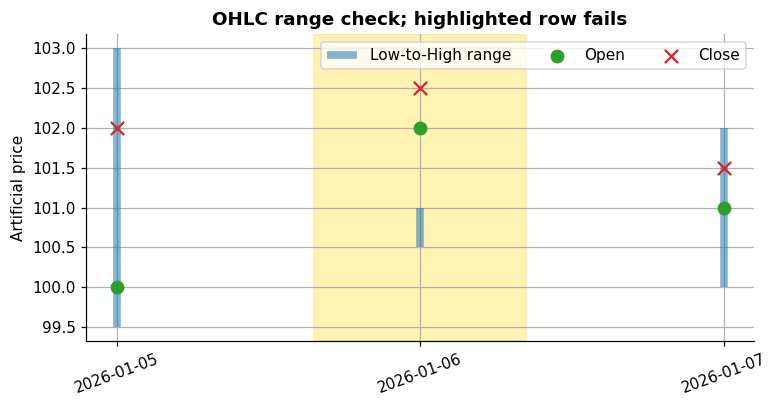

In [5]:
lesson_ohlcv = pd.DataFrame(
    {
        "Date": pd.to_datetime(["2026-01-05", "2026-01-06", "2026-01-07"]),
        "Open": [100.0, 102.0, 101.0],
        "High": [103.0, 101.0, 102.0],
        "Low": [99.5, 100.5, 100.0],
        "Close": [102.0, 102.5, 101.5],
        "Volume": [1_000_000, 1_100_000, 950_000],
    }
).set_index("Date")

ohlcv_audit = pd.DataFrame(index=lesson_ohlcv.index)
ohlcv_audit["low_not_above_open"] = lesson_ohlcv["Low"] <= lesson_ohlcv["Open"]
ohlcv_audit["low_not_above_close"] = lesson_ohlcv["Low"] <= lesson_ohlcv["Close"]
ohlcv_audit["high_not_below_open"] = lesson_ohlcv["High"] >= lesson_ohlcv["Open"]
ohlcv_audit["high_not_below_close"] = lesson_ohlcv["High"] >= lesson_ohlcv["Close"]
ohlcv_audit["volume_nonnegative"] = lesson_ohlcv["Volume"] >= 0
ohlcv_audit["row_passes_arithmetic"] = ohlcv_audit.all(axis=1)

display(lesson_ohlcv)
display(ohlcv_audit)
print("Rows failing arithmetic checks:", (~ohlcv_audit["row_passes_arithmetic"]).sum())

x_positions = np.arange(len(lesson_ohlcv))
fig, ax = plt.subplots()
ax.vlines(
    x_positions,
    lesson_ohlcv["Low"],
    lesson_ohlcv["High"],
    color="tab:blue",
    linewidth=5,
    alpha=0.55,
    label="Low-to-High range",
)
ax.scatter(x_positions, lesson_ohlcv["Open"], color="tab:green", s=65, label="Open", zorder=3)
ax.scatter(x_positions, lesson_ohlcv["Close"], color="tab:red", marker="x", s=75, label="Close", zorder=3)
failed_positions = np.flatnonzero(~ohlcv_audit["row_passes_arithmetic"].to_numpy())
for position in failed_positions:
    ax.axvspan(position - 0.35, position + 0.35, color="gold", alpha=0.30)
ax.set_xticks(x_positions, lesson_ohlcv.index.strftime("%Y-%m-%d"), rotation=20)
ax.set_ylabel("Artificial price")
ax.set_title("OHLC range check; highlighted row fails")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

assert (~ohlcv_audit["row_passes_arithmetic"]).sum() == 1

### Interpret the output


The January 6 row fails because the reported Close exceeds the reported High. In the chart, the red Close marker lies above the blue Low-to-High range inside the highlighted band. The correct response is not to raise High or lower Close without evidence. Display the source row, check the provider definition, and determine whether fields from different sessions or instruments were combined.


### Discussion questions

1. Which OHLC relations are arithmetic necessities under a common session definition?
2. What session information cannot be learned from the arithmetic checks?
3. Why is a nonnegative volume check insufficient to establish the meaning of Volume?
4. What evidence would justify correcting the January 6 row?

### Evidence to preserve

Save the input table, every Boolean range check, the failed row, your prediction, and one provider question that arithmetic cannot answer.

### First diagnostic action

When a range relation fails, display the entire original row and source definition before proposing any repair.

## Issue 5 — Which price field answers the return question?


Raw close, adjusted close, and a total-return index can answer different questions. A raw close may represent the quoted closing level. An adjusted series may apply provider-defined transformations for corporate actions. A total-return index may incorporate distributions under a reinvestment rule. Labels are not universal, and two providers may construct similarly named fields differently.

The artificial values below deliberately produce different returns. They illustrate why field choice changes the calculation; they do not reproduce a real provider adjustment formula.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Raw_Close,Provider_Adjusted_Close,Artificial_Total_Return_Index
2026-02-02,100.0,50.0,100.0
2026-02-03,50.0,50.0,100.5
2026-02-04,51.0,51.0,103.0


,Raw_Close,Provider_Adjusted_Close,Artificial_Total_Return_Index
2026-02-02,NaN,NaN,NaN
2026-02-03,-0.50,0.00,0.005000
2026-02-04,0.02,0.02,0.024876


Raw-close return on second date: -0.5
Adjusted-close return on second date: 0.0
Total-return-index return on second date: 0.004999999999999893


,Raw_Close,Provider_Adjusted_Close,Artificial_Total_Return_Index
Date,,,
2026-02-02,100.0,100.0,100.0
2026-02-03,50.0,100.0,100.5
2026-02-04,51.0,102.0,103.0


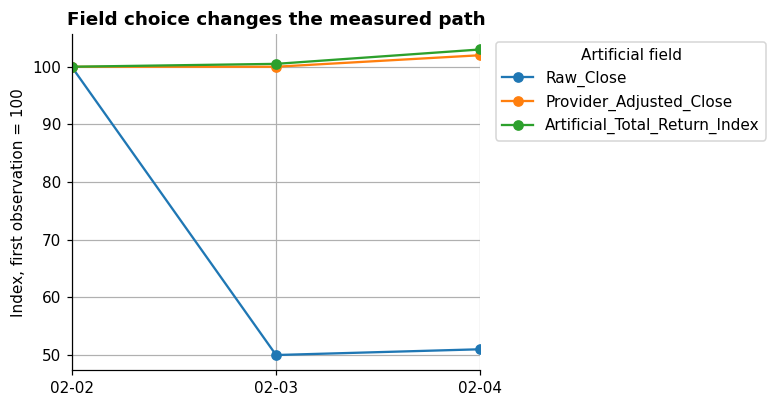

In [6]:
field_demo = pd.DataFrame(
    {
        "Raw_Close": [100.0, 50.0, 51.0],
        "Provider_Adjusted_Close": [50.0, 50.0, 51.0],
        "Artificial_Total_Return_Index": [100.0, 100.5, 103.0],
    },
    index=pd.to_datetime(["2026-02-02", "2026-02-03", "2026-02-04"]),
)

field_returns = field_demo.pct_change(fill_method=None)
display(field_demo)
display(field_returns.round(6))

print("Raw-close return on second date:", field_returns["Raw_Close"].iloc[1])
print("Adjusted-close return on second date:", field_returns["Provider_Adjusted_Close"].iloc[1])
print("Total-return-index return on second date:", field_returns["Artificial_Total_Return_Index"].iloc[1])

normalized_fields = field_demo.div(field_demo.iloc[0]).mul(100)
display(normalized_fields.round(2).rename_axis("Date"))
ax = normalized_fields.plot(marker="o")
ax.set_ylabel("Index, first observation = 100")
ax.set_title("Field choice changes the measured path")
ax.set_xticks(normalized_fields.index, normalized_fields.index.strftime("%m-%d"))
ax.legend(title="Artificial field", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

assert np.isclose(field_returns["Raw_Close"].iloc[1], -0.50)
assert np.isclose(field_returns["Provider_Adjusted_Close"].iloc[1], 0.0)

### Interpret the output


The three columns do not describe the same change in value. The normalized table and chart place every field at 100 initially, making the divergence visible without mixing their original scales. The example therefore cannot support the instruction to always use one named field. The analysis must first state whether it seeks quoted price change, a provider-adjusted change, or a distribution-inclusive holding return.


### Discussion questions

1. Which field would answer a narrowly defined raw price-change question?
2. What provider documentation is required before using an adjusted field?
3. How could a distribution be counted twice when mixing adjusted prices and a separate dividend column?
4. Why is choosing the field with the best historical performance invalid?

### Evidence to preserve

Save the three field definitions you would need, the return table, and a written field decision tied to one financial question.

### First diagnostic action

When returns differ across fields, stop and compare documented construction rules rather than selecting a column by name or outcome.

## Issue 6 — How does a stock split affect price and share count?


A stock split can change the quoted price per share and the number of shares held without creating the same proportional change in total position value. A raw per-share return across the event can therefore be economically misleading if share-count change is ignored.

This simplified artificial example assumes a two-for-one split, no other price movement, no fees, and exact adjustment at the boundary. Real data require the provider event record and effective-time convention.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Price_per_share,Shares,Position_value
Before split,100.0,1.0,100.0
After split,50.0,2.0,100.0


,Return_decimal,Return_percent
Raw per-share price,-0.5,-50.0
Position value,0.0,0.0


Raw per-share return: -0.5
Position value before: 100.0
Position value after: 100.0
Position-value return: 0.0


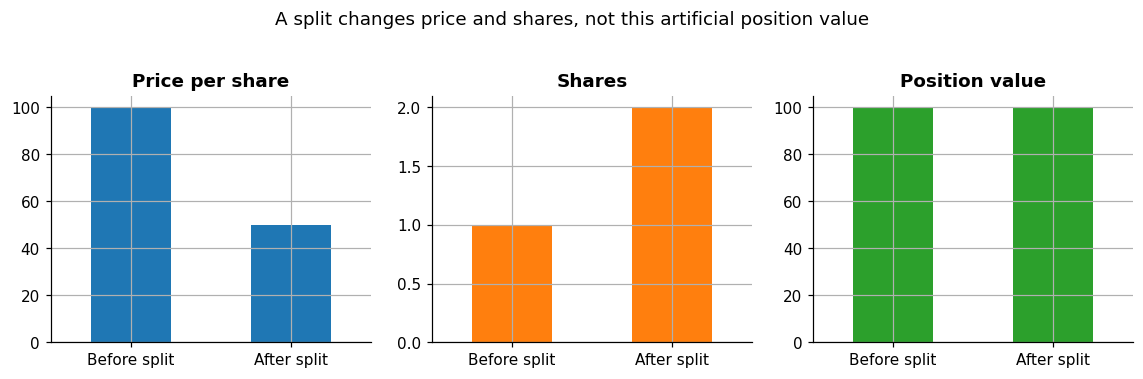

In [7]:
split_example = pd.Series(
    {
        "price_before": 100.0,
        "shares_before": 1.0,
        "split_ratio_new_per_old": 2.0,
        "price_after": 50.0,
        "shares_after": 2.0,
    }
)

raw_per_share_return = split_example["price_after"] / split_example["price_before"] - 1
value_before = split_example["price_before"] * split_example["shares_before"]
value_after = split_example["price_after"] * split_example["shares_after"]
position_value_return = value_after / value_before - 1

split_table = pd.DataFrame(
    {
        "Price_per_share": [split_example["price_before"], split_example["price_after"]],
        "Shares": [split_example["shares_before"], split_example["shares_after"]],
        "Position_value": [value_before, value_after],
    },
    index=["Before split", "After split"],
)
split_return_table = pd.DataFrame(
    {
        "Return_decimal": [raw_per_share_return, position_value_return],
        "Return_percent": [100 * raw_per_share_return, 100 * position_value_return],
    },
    index=["Raw per-share price", "Position value"],
)

display(split_table)
display(split_return_table.round(4))
print("Raw per-share return:", raw_per_share_return)
print("Position value before:", value_before)
print("Position value after:", value_after)
print("Position-value return:", position_value_return)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
for axis, column, color in zip(
    axes,
    ["Price_per_share", "Shares", "Position_value"],
    ["tab:blue", "tab:orange", "tab:green"],
):
    split_table[column].plot(kind="bar", ax=axis, color=color, rot=0)
    axis.set_title(column.replace("_", " "))
    axis.set_xlabel("")
fig.suptitle("A split changes price and shares, not this artificial position value", y=1.03)
plt.tight_layout()
plt.show()

assert np.isclose(raw_per_share_return, -0.50)
assert np.isclose(position_value_return, 0.0)

### Interpret the output


The negative 50% raw per-share return and zero position-value return answer different questions. The three panels show the price per share falling, the share count rising, and the artificial position value remaining unchanged. The example does not imply that every exact halving is a split; an authoritative corporate-action record is still required.


### Discussion questions

1. Why does the raw price return fail to describe the unchanged position value?
2. Which event fields are needed to verify the split ratio and effective date?
3. How would an incorrect split adjustment affect a momentum feature later in the course?
4. What double-counting error could occur if both adjusted prices and a manual split correction are applied?

### Evidence to preserve

Save the five inputs, both return calculations, the value identity, and a list of provider evidence needed for a real event.

### First diagnostic action

When a large price change coincides with a share-count event, compare raw price, adjusted field, split record, and position value before labeling it a loss.

## Issue 7 — How can a cash dividend change the return calculation?


A price return uses only beginning and ending prices. A simplified holding-period return can add a cash distribution received during the interval. The distribution timing, eligibility, tax treatment, reinvestment assumption, and currency must be defined before a real return is calculated.

The artificial example assumes one share, a cash distribution of 3 units, and no reinvestment or tax. It separates price change from distribution-inclusive value change.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Amount
Beginning price,100.0
Ending price,98.0
Cash distribution,3.0
Ending value plus cash,101.0


,Return_decimal,Return_percent
Price return,-0.02,-2.0
Simplified holding-period return,0.01,1.0


Price return: -0.020000000000000018
Simplified holding-period return: 0.010000000000000009


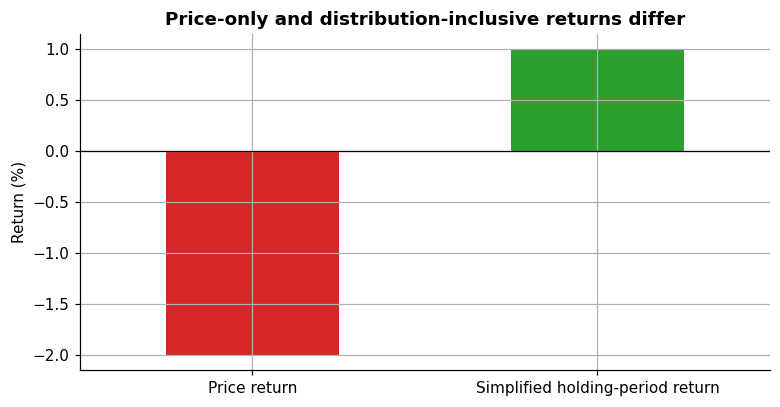

In [8]:
dividend_example = pd.Series(
    {
        "price_before": 100.0,
        "price_after": 98.0,
        "cash_distribution": 3.0,
    }
)

price_return = dividend_example["price_after"] / dividend_example["price_before"] - 1
holding_period_return = (
    dividend_example["price_after"] + dividend_example["cash_distribution"]
) / dividend_example["price_before"] - 1

dividend_value_table = pd.DataFrame(
    {
        "Amount": [
            dividend_example["price_before"],
            dividend_example["price_after"],
            dividend_example["cash_distribution"],
            dividend_example["price_after"] + dividend_example["cash_distribution"],
        ]
    },
    index=["Beginning price", "Ending price", "Cash distribution", "Ending value plus cash"],
)
dividend_return_table = pd.DataFrame(
    {
        "Return_decimal": [price_return, holding_period_return],
        "Return_percent": [100 * price_return, 100 * holding_period_return],
    },
    index=["Price return", "Simplified holding-period return"],
)

display(dividend_value_table)
display(dividend_return_table.round(4))
print("Price return:", price_return)
print("Simplified holding-period return:", holding_period_return)

ax = dividend_return_table["Return_percent"].plot(
    kind="bar",
    color=["tab:red", "tab:green"],
    rot=0,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Return (%)")
ax.set_title("Price-only and distribution-inclusive returns differ")
plt.tight_layout()
plt.show()

assert np.isclose(price_return, -0.02)
assert np.isclose(holding_period_return, 0.01)

### Interpret the output


The price fell by 2%, while price plus the assumed cash distribution increased value by 1%. The return table and bar chart keep those two quantities visually separate. The simplified calculation is not automatically a total-return series because it omits reinvestment timing, taxes, currency conversion, and provider conventions.


### Discussion questions

1. What eligibility condition must be satisfied for the investor to receive the cash distribution?
2. How would reinvestment timing change the required inputs?
3. When could an adjusted price plus a separate dividend create double counting?
4. Why should price return and holding-period return be labeled separately in a report?

### Evidence to preserve

Save the inputs, both returns, assumptions about distribution timing and reinvestment, and one limitation of the simplified formula.

### First diagnostic action

When a dividend-inclusive result looks unexpectedly high, inspect whether the price field already incorporates distributions.

## Issue 8 — Are units, currency, and percentage language consistent?


Many financial errors are unit errors rather than formula errors. A decimal return of 0.01, a percentage return of 1%, and 100 basis points describe the same change. A change from 4% to 5% is an increase of one percentage point, not one percent.

Currency and price units require the same discipline. A portfolio cannot combine values denominated in different currencies without documenting whether and how conversion occurs.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [9]:
unit_examples = pd.DataFrame(
    {
        "Input_label": ["decimal return", "percentage return", "basis points", "rate change"],
        "Input_value": [0.01, 1.0, 100.0, 5.0 - 4.0],
        "Converted_decimal": [0.01, 1.0 / 100, 100.0 / 10_000, np.nan],
        "Communication": ["1%", "1%", "1%", "1 percentage point"],
    }
)

display(unit_examples)
print("100 basis points in decimal units:", 100 / 10_000)
print("Rate change from 4% to 5%:", 5 - 4, "percentage point")
print("Relative increase from 4% to 5%:", 5.0 / 4.0 - 1.0)

assert np.isclose(unit_examples.loc[0, "Converted_decimal"], 0.01)
assert np.isclose(unit_examples.loc[1, "Converted_decimal"], 0.01)
assert np.isclose(unit_examples.loc[2, "Converted_decimal"], 0.01)
assert np.isclose(5.0 / 4.0 - 1.0, 0.25)

,Input_label,Input_value,Converted_decimal,Communication
0,decimal return,0.01,0.01,1%
1,percentage return,1.00,0.01,1%
2,basis points,100.00,0.01,1%
3,rate change,1.00,NaN,1 percentage point


100 basis points in decimal units: 0.01
Rate change from 4% to 5%: 1 percentage point
Relative increase from 4% to 5%: 0.25


### Interpret the output


The first three rows reconcile to the same decimal return. Moving from 4% to 5% is a change of one percentage point and a relative increase of 25%; those statements use different bases. The rate-change row should not be silently converted into an investment return. Units must appear beside both inputs and outputs.


### Discussion questions

1. What numerical mistake occurs when 1% is entered as 1 rather than 0.01?
2. Why is a rise from 4% to 5% not described as a one-percent increase?
3. Which exchange-rate convention would be needed before combining two currencies?
4. Where should units be recorded so they remain visible after columns are renamed?

### Evidence to preserve

Save the unit-conversion table, one corrected unit error, and a currency rule for any multi-asset calculation.

### First diagnostic action

When a return is implausibly large, inspect decimal, percentage, basis-point, currency, and per-share conventions before changing the model.

## Issue 9 — How is a simple return calculated?


A simple return compares the change in value with the beginning value. In words: divide the current price by the previous price and subtract one. Both prices must refer to the same asset, compatible field definition, currency, and adjacent holding interval.

The first observation has no earlier price inside the table, so its return remains missing. Filling that value with zero would create an unsupported holding interval.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Analysis_Price,Simple_Return
2026-01-05,100.0,NaN
2026-01-06,102.0,0.020000
2026-01-07,101.0,-0.009804
2026-01-08,104.0,0.029703
2026-01-09,103.0,-0.009615


Hand calculation for second date: 0.020000000000000018


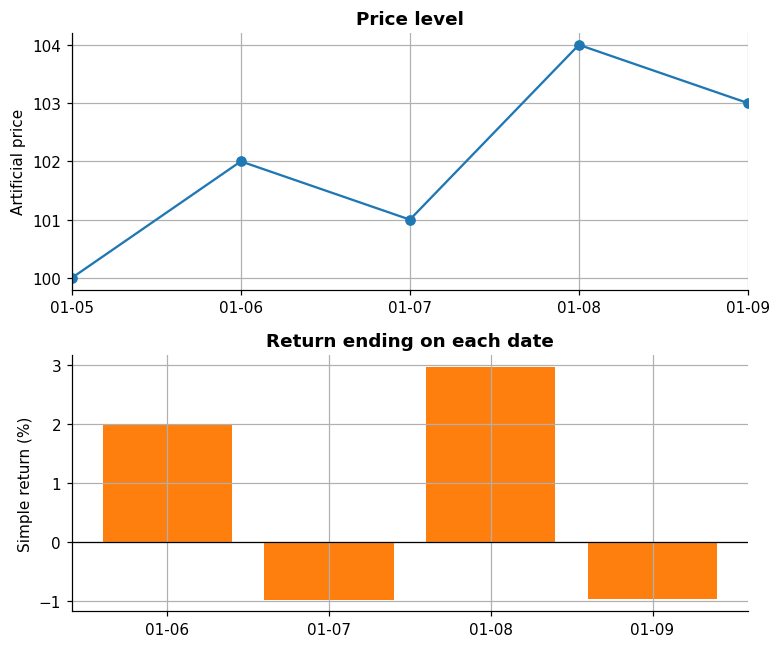

In [10]:
analysis_price = pd.Series(
    [100.0, 102.0, 101.0, 104.0, 103.0],
    index=pd.to_datetime(
        ["2026-01-05", "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09"]
    ),
    name="Analysis_Price",
)

simple_return = analysis_price.pct_change(fill_method=None).rename("Simple_Return")
simple_table = pd.concat([analysis_price, simple_return], axis=1)
display(simple_table.round(6))

hand_return_second_date = 102.0 / 100.0 - 1
print("Hand calculation for second date:", hand_return_second_date)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.0))
analysis_price.plot(ax=axes[0], marker="o", color="tab:blue")
axes[0].set_ylabel("Artificial price")
axes[0].set_title("Price level")
axes[0].set_xticks(analysis_price.index, analysis_price.index.strftime("%m-%d"))
return_percent = 100 * simple_return
axes[1].bar(return_percent.index.strftime("%m-%d"), return_percent.values, color="tab:orange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Simple return (%)")
axes[1].set_title("Return ending on each date")
plt.tight_layout()
plt.show()

assert pd.isna(simple_return.iloc[0])
assert np.isclose(simple_return.iloc[1], hand_return_second_date)
assert simple_return.notna().sum() == 4

### Interpret the output


Five prices create four within-table holding intervals. The upper chart shows the price levels, while the lower chart shows the return ending on each date. The return labeled January 6 describes the interval from the January 5 price endpoint to the January 6 endpoint under this table convention.


### Discussion questions

1. Why does the first return remain missing rather than equal zero?
2. What start and end timestamps does the January 6 return represent?
3. How would the calculation change if one price used a different currency?
4. Why is the arithmetic correct but the result still invalid if the two fields use incompatible adjustments?

### Evidence to preserve

Save the price-return table, the hand substitution for one interval, the missing first return, and the interval labels.

### First diagnostic action

When a simple return is unexpected, display the two endpoint prices, their definitions, and their timestamps before checking later calculations.

## Issue 10 — How is a log return calculated?


A log return is the natural logarithm of the current price divided by the previous price. It is defined only when both price levels are positive. Log returns add across adjacent intervals, but they are not identical to simple returns.

The code calculates the log price difference and rejects nonpositive prices before applying the logarithm.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Analysis_Price,Simple_Return,Log_Return
2026-01-05,100.0,NaN,NaN
2026-01-06,102.0,0.020000,0.019803
2026-01-07,101.0,-0.009804,-0.009852
2026-01-08,104.0,0.029703,0.029270
2026-01-09,103.0,-0.009615,-0.009662


Hand log return for second date: 0.01980262729617973


,Simple_Return,Log_Return
2026-01-05,NaN,NaN
2026-01-06,2.0000,1.9803
2026-01-07,-0.9804,-0.9852
2026-01-08,2.9703,2.9270
2026-01-09,-0.9615,-0.9662


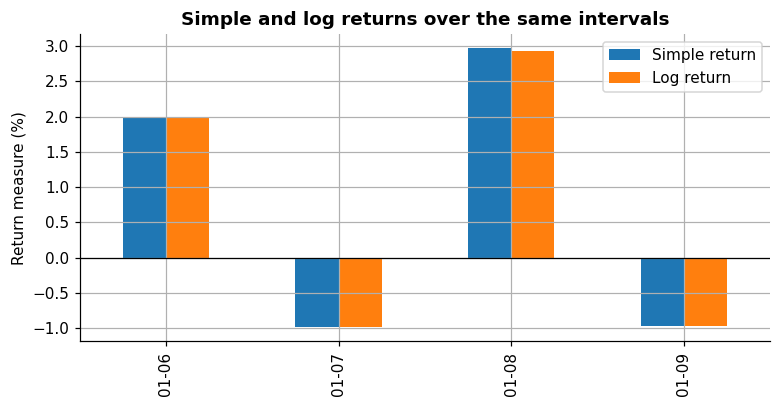

In [11]:
if not analysis_price.gt(0).all():
    raise ValueError("Log returns require positive price levels.")

log_return = np.log(analysis_price).diff().rename("Log_Return")
log_table = pd.concat([analysis_price, simple_return, log_return], axis=1)
display(log_table.round(6))

hand_log_return = np.log(102.0 / 100.0)
print("Hand log return for second date:", hand_log_return)

return_comparison_percent = pd.concat([simple_return, log_return], axis=1).mul(100)
display(return_comparison_percent.round(4))
return_comparison_plot = return_comparison_percent.dropna().copy()
return_comparison_plot.index = return_comparison_plot.index.strftime("%m-%d")
return_comparison_plot.columns = ["Simple return", "Log return"]
ax = return_comparison_plot.plot(kind="bar")
ax.axhline(0, color="black", linewidth=0.8, label="_nolegend_")
ax.set_ylabel("Return measure (%)")
ax.set_title("Simple and log returns over the same intervals")
ax.legend()
plt.tight_layout()
plt.show()

assert pd.isna(log_return.iloc[0])
assert np.isclose(log_return.iloc[1], hand_log_return)
assert log_return.notna().sum() == 4

### Interpret the output


The second-date log return is slightly below the 2% simple return. The side-by-side table and bars compare the two measures only on matching holding intervals. For small changes they can look similar, but the difference becomes more visible for large price movements.


### Discussion questions

1. Why must price levels be positive before a log return is calculated?
2. What advantage does additivity give when adjacent intervals are combined?
3. Why should a report label log and simple returns rather than call both return?
4. Would a log return itself solve a corporate-action problem in the input price? Explain.

### Evidence to preserve

Save the positivity check, log-return table, hand calculation, and a sentence distinguishing the two return definitions.

### First diagnostic action

When a logarithm produces infinity or an error, inspect the original price for zero, negative, missing, or incorrectly scaled values.

## Issue 11 — How do simple and log returns reconcile?


Simple and log returns are linked exactly: one plus the simple return equals the exponential of the log return. This identity provides a useful implementation check. It does not decide which return definition best answers the financial question.

The example converts log returns back to simple returns and measures the largest numerical difference.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [12]:
simple_from_log = np.expm1(log_return).rename("Simple_From_Log")
reconciliation = pd.concat(
    [simple_return, log_return, simple_from_log],
    axis=1,
)
reconciliation["Absolute_Difference"] = (
    reconciliation["Simple_Return"] - reconciliation["Simple_From_Log"]
).abs()

display(reconciliation.round(12))
max_difference = reconciliation["Absolute_Difference"].max()
print("Maximum reconciliation difference:", max_difference)

assert max_difference < 1e-12

,Simple_Return,Log_Return,Simple_From_Log,Absolute_Difference
2026-01-05,NaN,NaN,NaN,NaN
2026-01-06,0.020000,0.019803,0.020000,0.0
2026-01-07,-0.009804,-0.009852,-0.009804,0.0
2026-01-08,0.029703,0.029270,0.029703,0.0
2026-01-09,-0.009615,-0.009662,-0.009615,0.0


Maximum reconciliation difference: 8.708311849403572e-16


### Interpret the output


The difference is at floating-point precision. If the two columns fail to reconcile materially, they were probably calculated from different prices, different intervals, or an incorrect percentage conversion.


### Discussion questions

1. What does a passed reconciliation check establish, and what does it not establish?
2. How could two correctly calculated return columns fail because their date labels refer to different intervals?
3. Why is a tiny floating-point difference acceptable but a one-percentage-point difference not?
4. Which return would you use for a wealth index, and how would you justify the choice?

### Evidence to preserve

Save the reconciliation table, tolerance, maximum difference, and one explanation for a possible failed identity.

### First diagnostic action

When the identity fails, compare the two source price columns and interval endpoints before changing numerical tolerances.

## Issue 12 — Why are multi-period simple returns compounded?


Simple returns describe proportional changes in wealth. When wealth changes across adjacent periods, the next return applies to the wealth remaining after the previous period. Multi-period simple return therefore multiplies one plus each return and subtracts one; adding simple returns ignores this changing base.

The difference between adding and compounding is small for short, low-volatility paths but can become material.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Simple_Return
Period 1,0.10
Period 2,-0.10
Period 3,0.05


Added simple returns: 0.05
Compounded simple return: 0.03950000000000009


,Simple_Return,Growth_Factor,Compounded_Wealth,Added_Return_Approximation
Period 1,0.10,1.10,1.1000,1.10
Period 2,-0.10,0.90,0.9900,1.00
Period 3,0.05,1.05,1.0395,1.05


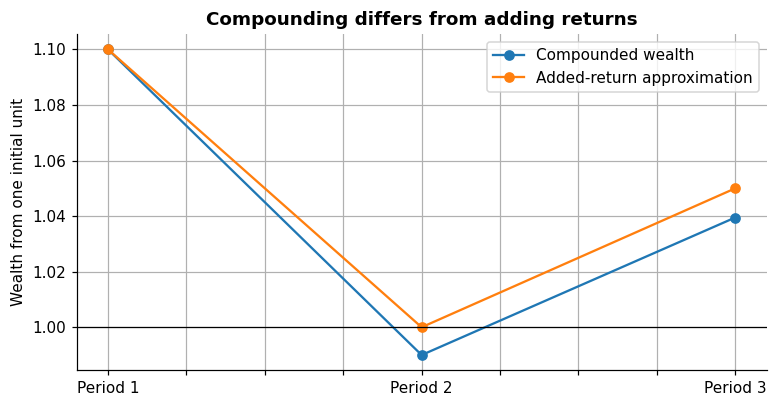

In [13]:
period_returns = pd.Series(
    [0.10, -0.10, 0.05],
    index=["Period 1", "Period 2", "Period 3"],
    name="Simple_Return",
)

added_return = period_returns.sum()
compounded_return = (1.0 + period_returns).prod() - 1.0

display(period_returns.to_frame())
print("Added simple returns:", added_return)
print("Compounded simple return:", compounded_return)

compounding_table = period_returns.to_frame()
compounding_table["Growth_Factor"] = 1.0 + compounding_table["Simple_Return"]
compounding_table["Compounded_Wealth"] = compounding_table["Growth_Factor"].cumprod()
compounding_table["Added_Return_Approximation"] = 1.0 + compounding_table["Simple_Return"].cumsum()
display(compounding_table.round(4))

ax = compounding_table[["Compounded_Wealth", "Added_Return_Approximation"]].plot(marker="o")
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set_ylabel("Wealth from one initial unit")
ax.set_title("Compounding differs from adding returns")
ax.legend(["Compounded wealth", "Added-return approximation"])
plt.tight_layout()
plt.show()

manual_terminal_wealth = 1.0 * 1.10 * 0.90 * 1.05
assert np.isclose(compounded_return, manual_terminal_wealth - 1.0)
assert not np.isclose(added_return, compounded_return)

### Interpret the output


The added return is 5%, while the compounded return reflects the changing wealth base and is lower. The table exposes each growth factor, and the chart shows the compounded wealth path separating from the added-return approximation. A 10% gain followed by a 10% loss does not return wealth to its starting value.


### Discussion questions

1. Why do equal positive and negative percentage returns fail to cancel?
2. When might adding log returns be valid even though adding simple returns is not?
3. How would a missing middle period affect the interpretation of the compounded path?
4. What interval information is needed before three returns can be compounded together?

### Evidence to preserve

Save the return path, added result, compounded result, hand wealth calculation, and a sentence explaining the changing base.

### First diagnostic action

When multi-period results disagree, reconstruct wealth one interval at a time before inspecting summary formulas.

## Issue 13 — What does a wealth index show?


A wealth index shows how one unit of initial wealth changes along a return path under stated reinvestment and cash-flow assumptions. Starting at one makes proportional changes easy to inspect. The path reveals drawdowns and recovery patterns that a terminal return alone cannot show.

For a price-only series with no external cash flows and compatible endpoints, terminal wealth should equal final price divided by initial price.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Analysis_Price,Simple_Return,Wealth_Index
2026-01-05,100.0,NaN,1.00
2026-01-06,102.0,0.020000,1.02
2026-01-07,101.0,-0.009804,1.01
2026-01-08,104.0,0.029703,1.04
2026-01-09,103.0,-0.009615,1.03


Terminal wealth from returns: 1.03
Endpoint price ratio: 1.03


,Wealth_from_returns,Normalized_price
2026-01-05,1.00,1.00
2026-01-06,1.02,1.02
2026-01-07,1.01,1.01
2026-01-08,1.04,1.04
2026-01-09,1.03,1.03


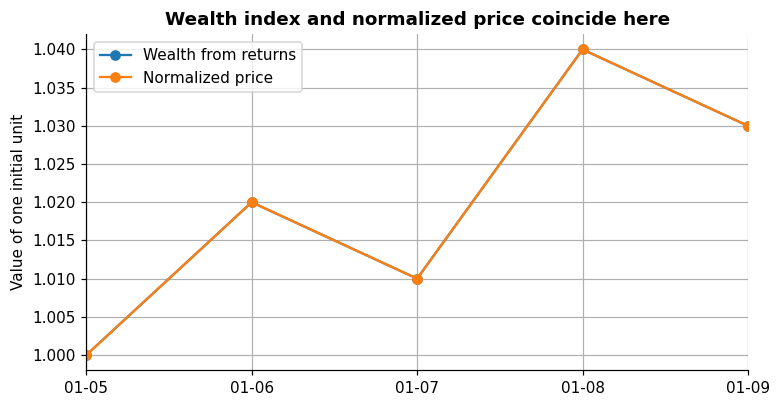

In [14]:
wealth_index = (1.0 + simple_return.fillna(0.0)).cumprod().rename("Wealth_Index")
wealth_table = pd.concat([analysis_price, simple_return, wealth_index], axis=1)
display(wealth_table.round(6))

terminal_from_returns = wealth_index.iloc[-1]
terminal_from_prices = analysis_price.iloc[-1] / analysis_price.iloc[0]

print("Terminal wealth from returns:", terminal_from_returns)
print("Endpoint price ratio:", terminal_from_prices)

wealth_identity_plot = pd.DataFrame(
    {
        "Wealth_from_returns": wealth_index,
        "Normalized_price": analysis_price / analysis_price.iloc[0],
    }
)
display(wealth_identity_plot.round(6))
ax = wealth_identity_plot.plot(marker="o")
ax.set_ylabel("Value of one initial unit")
ax.set_title("Wealth index and normalized price coincide here")
ax.set_xticks(wealth_identity_plot.index, wealth_identity_plot.index.strftime("%m-%d"))
ax.legend(["Wealth from returns", "Normalized price"])
plt.tight_layout()
plt.show()

assert np.isclose(wealth_index.iloc[0], 1.0)
assert np.isclose(terminal_from_returns, terminal_from_prices)

### Interpret the output


The first missing return is replaced with zero only for initializing the wealth index at one; it is not reclassified as an observed holding return. In this price-only example, the normalized-price and wealth-index lines overlap, visually confirming the endpoint identity. The identity would need a different interpretation if external cash flows or incompatible price adjustments were present.


### Discussion questions

1. Why is zero used for initialization but retained as missing in the return table?
2. What path information is lost when only terminal wealth is reported?
3. How would a deposit or withdrawal break the simple endpoint identity?
4. Why must a wealth chart state whether distributions and costs are included?

### Evidence to preserve

Save the wealth table, initialization rule, endpoint identity, and one interpretation of a rise and fall in the path.

### First diagnostic action

When terminal wealth does not equal the endpoint ratio, inspect return definition, cash flows, missing-value fills, and corporate-action treatment.

## Issue 14 — What is the difference between arithmetic and geometric mean returns?


The arithmetic mean averages periodic returns. The geometric mean is the constant per-period rate that reproduces the compounded terminal wealth over the same number of valid intervals. They answer different questions and need not be equal.

For simple returns greater than minus 100%, the geometric mean cannot exceed the arithmetic mean. It is strictly lower when the valid periodic returns are not all equal.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Value,Unit
Arithmetic_mean,0.007571,decimal return per period
Geometric_mean,0.007417,decimal return per period
Observed_terminal_wealth,1.030000,wealth
Wealth_from_geometric_mean,1.030000,wealth


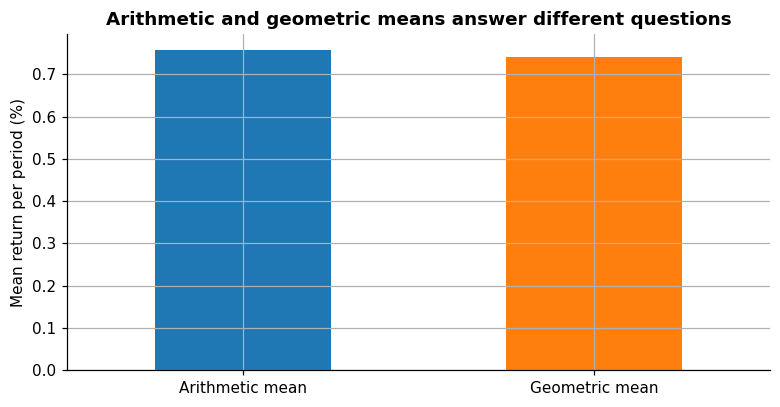

In [15]:
valid_returns = simple_return.dropna()
arithmetic_mean = valid_returns.mean()
geometric_mean = (1.0 + valid_returns).prod() ** (1.0 / len(valid_returns)) - 1.0

reproduced_terminal_wealth = (1.0 + geometric_mean) ** len(valid_returns)
observed_terminal_wealth = (1.0 + valid_returns).prod()

summary_means = pd.DataFrame(
    {
        "Value": [
            arithmetic_mean,
            geometric_mean,
            observed_terminal_wealth,
            reproduced_terminal_wealth,
        ],
        "Unit": ["decimal return per period", "decimal return per period", "wealth", "wealth"],
    },
    index=[
        "Arithmetic_mean",
        "Geometric_mean",
        "Observed_terminal_wealth",
        "Wealth_from_geometric_mean",
    ],
)
display(summary_means.round(8))

mean_comparison_percent = pd.Series(
    {"Arithmetic mean": 100 * arithmetic_mean, "Geometric mean": 100 * geometric_mean}
)
ax = mean_comparison_percent.plot(kind="bar", color=["tab:blue", "tab:orange"], rot=0)
ax.set_ylabel("Mean return per period (%)")
ax.set_title("Arithmetic and geometric means answer different questions")
plt.tight_layout()
plt.show()

assert geometric_mean <= arithmetic_mean + 1e-15
assert np.isclose(reproduced_terminal_wealth, observed_terminal_wealth)

### Interpret the output


The geometric mean reproduces terminal wealth; the arithmetic mean describes the average one-period return. The summary table keeps return units separate from wealth units, and the bar chart compares only the two per-period means. Neither should be annualized without stating the observation frequency and annualization convention.


### Discussion questions

1. Which mean answers the question of a constant per-period compounded rate?
2. Why does return variability create a gap between the two means?
3. What happens to the geometric mean if any simple return is minus 100%?
4. Why must the number and frequency of valid intervals accompany either mean?

### Evidence to preserve

Save both means, the reproduced-wealth identity, the valid interval count, and an explanation of the question answered by each statistic.

### First diagnostic action

When the geometric mean is undefined, inspect whether one plus any simple return is zero or negative and return to the source data.

## Issue 15 — Are dates parsed, unique, and sorted?


Financial calculations depend on chronological order. Text labels can sort incorrectly, duplicate timestamps can create ambiguous returns, and silent parsing assumptions can reverse day and month. Parsing should therefore be explicit, followed by uniqueness and monotonic-order checks.

The example contains unsorted input and a duplicate date. It audits the original order before creating a sorted view; it does not choose which duplicate is correct.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [16]:
date_records = pd.DataFrame(
    {
        "Date_text": ["2026-03-03", "2026-03-02", "2026-03-03", "2026-03-05"],
        "Price": [51.0, 50.0, 51.2, 52.0],
    }
)
date_records["Parsed_Date"] = pd.to_datetime(date_records["Date_text"], format="%Y-%m-%d")

date_audit = pd.Series(
    {
        "rows": len(date_records),
        "parse_failures": int(date_records["Parsed_Date"].isna().sum()),
        "duplicate_dates_beyond_first": int(date_records["Parsed_Date"].duplicated().sum()),
        "input_is_sorted": bool(date_records["Parsed_Date"].is_monotonic_increasing),
    }
)

display(date_records)
display(date_audit)
display(date_records.sort_values("Parsed_Date"))

assert date_audit["parse_failures"] == 0
assert date_audit["duplicate_dates_beyond_first"] == 1
assert not date_audit["input_is_sorted"]

,Date_text,Price,Parsed_Date
0,2026-03-03,51.0,2026-03-03
1,2026-03-02,50.0,2026-03-02
2,2026-03-03,51.2,2026-03-03
3,2026-03-05,52.0,2026-03-05


rows                                4
parse_failures                      0
duplicate_dates_beyond_first        1
input_is_sorted                 False
dtype: object

,Date_text,Price,Parsed_Date
1,2026-03-02,50.0,2026-03-02
0,2026-03-03,51.0,2026-03-03
2,2026-03-03,51.2,2026-03-03
3,2026-03-05,52.0,2026-03-05


### Interpret the output


Sorting can correct order but cannot resolve the duplicate. Selecting the first, last, average, or maximum would each create a different price history and requires a documented source rule.


### Discussion questions

1. Why should the original row order be preserved even after creating a sorted table?
2. What evidence would justify choosing one of the duplicate prices?
3. How could an ambiguous date format change the holding interval?
4. Why is a unique date index insufficient when multiple assets or venues share timestamps?

### Evidence to preserve

Save the original table, parsed dates, audit summary, sorted view, and an unresolved duplicate decision.

### First diagnostic action

When dates behave unexpectedly, display raw text, parsing format, parsed value, duplicate rows, and sorted order before calculating returns.

## Issue 16 — How should missing, stale, invalid, and extreme values be treated?


Missing, stale, invalid, and extreme describe different observations. A missing value is absent. A stale-price flag marks an unchanged value under a stated rule but does not prove an error. A nonpositive price requires investigation before an ordinary return calculation; a zero may represent total loss, a placeholder, or a data error, and a log return is not defined at zero. An extreme return is a review flag whose threshold is an analysis choice, not an automatic deletion rule.

The example preserves every original row and adds flags. The 25% extreme-return threshold is an artificial diagnostic setting.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Price,missing,nonpositive,unchanged_from_previous,raw_simple_return,infinite_return,finite_extreme_return
2026-04-01,100.0,False,False,False,NaN,False,False
2026-04-02,100.0,False,False,True,0.000000,False,False
2026-04-03,NaN,True,False,False,NaN,False,False
2026-04-06,0.0,False,True,False,NaN,False,False
2026-04-07,150.0,False,False,False,inf,True,False
2026-04-08,149.0,False,False,False,-0.006667,False,False
2026-04-09,210.0,False,False,False,0.409396,False,True


,Flagged_rows
Diagnostic flag,
missing,1
nonpositive,1
unchanged_from_previous,1
infinite_return,1
finite_extreme_return,1


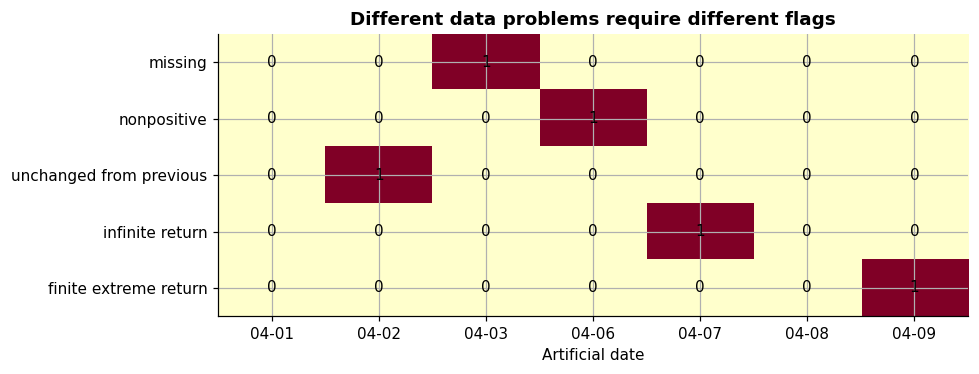

In [17]:
quality_prices = pd.Series(
    [100.0, 100.0, np.nan, 0.0, 150.0, 149.0, 210.0],
    index=pd.to_datetime(
        [
            "2026-04-01",
            "2026-04-02",
            "2026-04-03",
            "2026-04-06",
            "2026-04-07",
            "2026-04-08",
            "2026-04-09",
        ]
    ),
    name="Price",
)

quality_audit = quality_prices.to_frame()
quality_audit["missing"] = quality_audit["Price"].isna()
quality_audit["nonpositive"] = quality_audit["Price"].notna() & quality_audit["Price"].le(0)
quality_audit["unchanged_from_previous"] = quality_audit["Price"].eq(quality_audit["Price"].shift(1))
quality_audit["raw_simple_return"] = quality_audit["Price"].pct_change(fill_method=None)
quality_audit["infinite_return"] = np.isinf(quality_audit["raw_simple_return"])
quality_audit["finite_extreme_return"] = (
    np.isfinite(quality_audit["raw_simple_return"])
    & quality_audit["raw_simple_return"].abs().gt(0.25)
)

display(quality_audit)
quality_flag_columns = [
    "missing",
    "nonpositive",
    "unchanged_from_previous",
    "infinite_return",
    "finite_extreme_return",
]
quality_flag_summary = (
    quality_audit[quality_flag_columns]
    .sum()
    .rename("Flagged_rows")
    .rename_axis("Diagnostic flag")
    .to_frame()
)
display(quality_flag_summary)

fig, ax = plt.subplots(figsize=(9.0, 3.5))
flag_matrix = quality_audit[quality_flag_columns].astype(int).T
image = ax.imshow(flag_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(np.arange(len(flag_matrix.index)), [name.replace("_", " ") for name in flag_matrix.index])
ax.set_xticks(np.arange(len(flag_matrix.columns)), flag_matrix.columns.strftime("%m-%d"))
ax.set_xlabel("Artificial date")
ax.set_title("Different data problems require different flags")
for row in range(flag_matrix.shape[0]):
    for column in range(flag_matrix.shape[1]):
        ax.text(column, row, str(flag_matrix.iat[row, column]), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

assert quality_audit["missing"].sum() == 1
assert quality_audit["nonpositive"].sum() == 1
assert quality_audit["unchanged_from_previous"].sum() == 1
assert quality_audit["infinite_return"].sum() == 1
assert quality_audit["finite_extreme_return"].sum() == 1

### Interpret the output


The unchanged price is flagged but not declared wrong. The return from zero to 150 is infinite and cannot be interpreted until the zero is resolved. The finite increase from 149 to 210 separately triggers the illustrative 25% review threshold. The count table summarizes each flag, while the heatmap preserves which dates triggered which checks. Flags support investigation; they do not supply repairs.


### Discussion questions

1. When could an unchanged price be legitimate rather than stale?
2. Why should a missing value not be automatically forward-filled?
3. What financial event might explain an extreme return without making it erroneous?
4. Which decisions require provider evidence, and which are analysis conventions?

### Evidence to preserve

Save the original series, separate infinite and finite-extreme flags, the artificial threshold, unresolved cases, and the effect of any proposed treatment on retained rows.

### First diagnostic action

When an extreme or infinite return appears, inspect both endpoint prices and nearby corporate-action or trading-status records before filtering.

## Issue 17 — Is a missing calendar date a missing trading observation?


Markets do not necessarily trade every calendar day. Weekends, holidays, special closures, and asset-specific suspensions can create dates with no observation. A calendar gap becomes a data-quality problem only after comparison with the correct market calendar and session definition.

The example uses an explicitly artificial session schedule. It shows why a business-day generator is not authoritative evidence for any real exchange.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [18]:
calendar_days = pd.date_range("2026-01-02", "2026-01-08", freq="D")
observed_sessions = pd.DatetimeIndex(
    pd.to_datetime(["2026-01-02", "2026-01-05", "2026-01-06", "2026-01-08"])
)
artificial_closed_sessions = pd.DatetimeIndex(pd.to_datetime(["2026-01-07"]))

calendar_audit = pd.DataFrame(index=calendar_days)
calendar_audit["day_name"] = calendar_audit.index.day_name()
calendar_audit["observed"] = calendar_audit.index.isin(observed_sessions)
calendar_audit["weekend"] = calendar_audit.index.dayofweek >= 5
calendar_audit["artificial_scheduled_close"] = calendar_audit.index.isin(
    artificial_closed_sessions
)
calendar_audit["unresolved_gap"] = (
    ~calendar_audit["observed"]
    & ~calendar_audit["weekend"]
    & ~calendar_audit["artificial_scheduled_close"]
)

display(calendar_audit)
print("Unresolved gaps:", calendar_audit["unresolved_gap"].sum())

assert calendar_audit["unresolved_gap"].sum() == 0

,day_name,observed,weekend,artificial_scheduled_close,unresolved_gap
2026-01-02,Friday,True,False,False,False
2026-01-03,Saturday,False,True,False,False
2026-01-04,Sunday,False,True,False,False
2026-01-05,Monday,True,False,False,False
2026-01-06,Tuesday,True,False,False,False
2026-01-07,Wednesday,False,False,True,False
2026-01-08,Thursday,True,False,False,False


Unresolved gaps: 0


### Interpret the output


Weekend dates and the explicitly stated artificial closure are not treated as missing observations. For a real asset, the same conclusion would require the official calendar, time zone, and session information.


### Discussion questions

1. Why can a weekday gap be legitimate?
2. Which calendar should be used when assets trade on different venues?
3. How would an early close affect the meaning of an intraday observation?
4. Why is pandas business-day frequency not proof of an exchange session?

### Evidence to preserve

Save the observed dates, stated artificial closure, full calendar audit, and the source required for a real calendar.

### First diagnostic action

When a date appears missing, compare it with the authoritative venue calendar and asset trading status before filling or deleting rows.

## Issue 18 — Do timestamps and frequency labels describe the same interval?


A timestamp needs a time zone and boundary meaning. A label such as daily does not state whether it is a calendar-day close, exchange-session close, UTC aggregation, or provider-defined bar. Converting time zones changes labels but not the underlying instant; aggregating observations changes the interval represented.

The example converts artificial New York timestamps to UTC and separately constructs daily last observations from artificial intraday UTC prices. A daily last observation is not automatically an exchange-session close.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Local_session_label,Same_instant_in_UTC
0,2026-01-05 16:00:00-05:00,2026-01-05 21:00:00+00:00
1,2026-01-06 16:00:00-05:00,2026-01-06 21:00:00+00:00


,Artificial_Intraday_Price
2026-01-05 15:00:00+00:00,100.0
2026-01-05 21:00:00+00:00,101.0
2026-01-06 15:00:00+00:00,102.0
2026-01-06 21:00:00+00:00,101.5


,Daily_Last_UTC
2026-01-05 00:00:00+00:00,101.0
2026-01-06 00:00:00+00:00,101.5


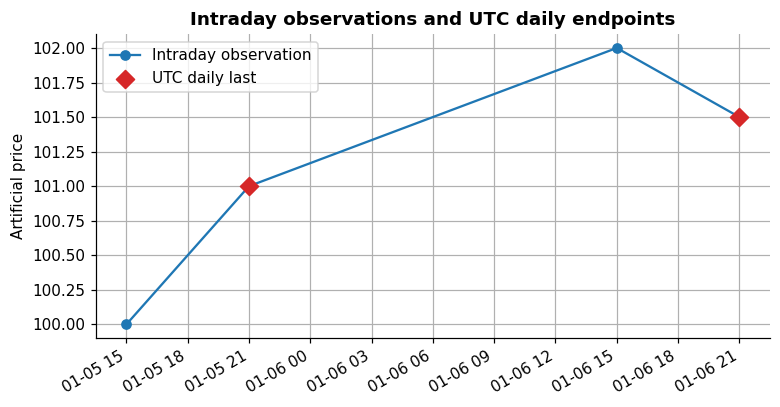

In [19]:
local_times = pd.DatetimeIndex(
    pd.to_datetime(["2026-01-05 16:00", "2026-01-06 16:00"])
).tz_localize("America/New_York")
utc_times = local_times.tz_convert("UTC")

time_conversion = pd.DataFrame(
    {
        "Local_session_label": local_times.astype(str),
        "Same_instant_in_UTC": utc_times.astype(str),
    }
)
display(time_conversion)

intraday_prices = pd.Series(
    [100.0, 101.0, 102.0, 101.5],
    index=pd.DatetimeIndex(
        pd.to_datetime(
            [
                "2026-01-05 15:00+00:00",
                "2026-01-05 21:00+00:00",
                "2026-01-06 15:00+00:00",
                "2026-01-06 21:00+00:00",
            ],
            utc=True,
        )
    ),
    name="Artificial_Intraday_Price",
)
daily_last_utc = intraday_prices.resample("D").last().dropna().rename("Daily_Last_UTC")
daily_last_observation_points = intraday_prices.groupby(intraday_prices.index.normalize()).tail(1)

display(intraday_prices.to_frame())
display(daily_last_utc.to_frame())

ax = intraday_prices.plot(marker="o", label="Intraday observation")
ax.scatter(
    daily_last_observation_points.index,
    daily_last_observation_points.values,
    color="tab:red",
    marker="D",
    s=70,
    label="UTC daily last",
    zorder=3,
)
ax.set_ylabel("Artificial price")
ax.set_title("Intraday observations and UTC daily endpoints")
ax.legend()
plt.tight_layout()
plt.show()

assert len(daily_last_utc) == 2
assert utc_times[0].tzinfo is not None

### Interpret the output


The local and UTC timestamps identify the same instants with different labels. The daily aggregation, however, applies a UTC calendar-day rule. In the chart, the diamond markers identify the observations selected by that daily-last rule. A real exchange-session close may require a different boundary.


### Discussion questions

1. What information is lost when a time zone is removed?
2. Why can a UTC calendar day differ from a local exchange session?
3. Which aggregation functions would define Open, High, Low, Close, and Volume from intraday rows?
4. How could daylight-saving changes affect a fixed UTC-time assumption?

### Evidence to preserve

Save the original zone, converted timestamps, aggregation rule, resulting daily endpoints, and a statement of what daily means.

### First diagnostic action

When two daily datasets disagree, compare time zone, session boundary, included trading hours, and aggregation rule before comparing values.

## Issue 19 — Do multiple assets share a common holding interval?


A portfolio return combines asset returns that describe the same start and end boundaries. Calculating each asset return first and then joining by end date can hide different start dates when one asset has a missing price. A safer approach for this lesson is to build a common endpoint price table first and then calculate returns.

The artificial Asset E price is missing on March 4. The example does not forward-fill it.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Asset_D,Asset_E
2026-03-02,80.0,40.0
2026-03-03,82.0,39.0
2026-03-04,81.0,NaN
2026-03-05,84.0,42.0
2026-03-06,83.0,43.0


,Asset_D,Asset_E
2026-03-02,80.0,40.0
2026-03-03,82.0,39.0
2026-03-05,84.0,42.0
2026-03-06,83.0,43.0


,Interval_start,Interval_end
2026-03-02,NaT,2026-03-02
2026-03-03,2026-03-02,2026-03-03
2026-03-05,2026-03-03,2026-03-05
2026-03-06,2026-03-05,2026-03-06


,Asset_D,Asset_E
2026-03-02,NaN,NaN
2026-03-03,0.025000,-0.025000
2026-03-05,0.024390,0.076923
2026-03-06,-0.011905,0.023810


,Asset_D,Asset_E
2026-03-02,100.00,100.0
2026-03-03,102.50,97.5
2026-03-04,101.25,NaN
2026-03-05,105.00,105.0
2026-03-06,103.75,107.5


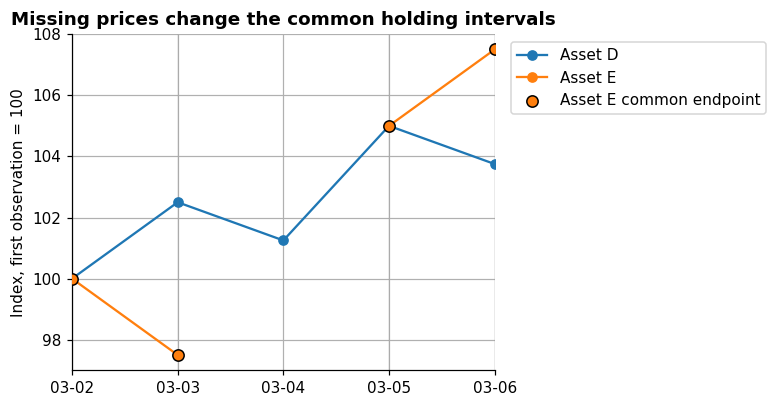

In [20]:
multi_asset_prices = pd.DataFrame(
    {
        "Asset_D": [80.0, 82.0, 81.0, 84.0, 83.0],
        "Asset_E": [40.0, 39.0, np.nan, 42.0, 43.0],
    },
    index=pd.to_datetime(
        ["2026-03-02", "2026-03-03", "2026-03-04", "2026-03-05", "2026-03-06"]
    ),
)

common_prices = multi_asset_prices.dropna(how="any")
common_returns = common_prices.pct_change(fill_method=None)

intervals = pd.DataFrame(
    {
        "Interval_start": common_prices.index.to_series().shift(1),
        "Interval_end": common_prices.index,
    },
    index=common_prices.index,
)

display(multi_asset_prices)
display(common_prices)
display(intervals)
display(common_returns.round(6))

normalized_multi_asset = multi_asset_prices.div(multi_asset_prices.iloc[0]).mul(100)
display(normalized_multi_asset.round(2))
normalized_multi_asset_plot = normalized_multi_asset.rename(
    columns={"Asset_D": "Asset D", "Asset_E": "Asset E"}
)
ax = normalized_multi_asset_plot.plot(marker="o")
for date in common_prices.index:
    ax.axvline(date, color="grey", alpha=0.12, linewidth=1)
ax.scatter(
    common_prices.index,
    normalized_multi_asset.loc[common_prices.index, "Asset_E"],
    color="tab:orange",
    edgecolor="black",
    s=55,
    label="Asset E common endpoint",
    zorder=4,
)
ax.set_ylabel("Index, first observation = 100")
ax.set_title("Missing prices change the common holding intervals")
ax.set_xticks(normalized_multi_asset.index, normalized_multi_asset.index.strftime("%m-%d"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

assert len(common_prices) == 4
assert common_returns.notna().all(axis=1).sum() == 3

### Interpret the output


The return ending March 5 spans March 3 to March 5 for both assets. The normalized chart leaves Asset E's missing observation visible and marks its retained common endpoints. Asset D also has a March 3-to-March 4 daily return, but Asset E does not; combining those differently timed returns would not describe one portfolio interval.


### Discussion questions

1. Why is forward-filling Asset E not a neutral repair?
2. Which common interval is created after the March 4 row is excluded?
3. What information is lost by restricting all assets to common endpoints?
4. When might an alternative asynchronous-data method be justified, and what additional assumptions would it require?

### Evidence to preserve

Save the original table, missing-value audit, common endpoint table, explicit interval labels, and common return table.

### First diagnostic action

When component returns share an end label but seem inconsistent, display both start and end boundaries for every asset.

## Issue 20 — What does a one-period fixed-weight portfolio return mean?


A one-period fixed-weight portfolio return is the weighted sum of component returns over one common holding interval, using weights established before that interval begins. The weights must be finite, aligned to the asset labels, and sum to one under a fully invested no-leverage convention.

This calculation is portfolio arithmetic, not a method for choosing weights. Week 8 studies how weights are selected and rebalanced.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Starting_Weight
Asset_D,0.7
Asset_E,0.3


,Asset_D,Asset_E,Portfolio_Return
2026-03-02,NaN,NaN,NaN
2026-03-03,0.025000,-0.025000,0.01000
2026-03-05,0.024390,0.076923,0.04015
2026-03-06,-0.011905,0.023810,-0.00119


,Asset_D_Contribution,Asset_E_Contribution,Portfolio_Return
2026-03-02,NaN,NaN,NaN
2026-03-03,0.017500,-0.007500,0.01000
2026-03-05,0.017073,0.023077,0.04015
2026-03-06,-0.008333,0.007143,-0.00119


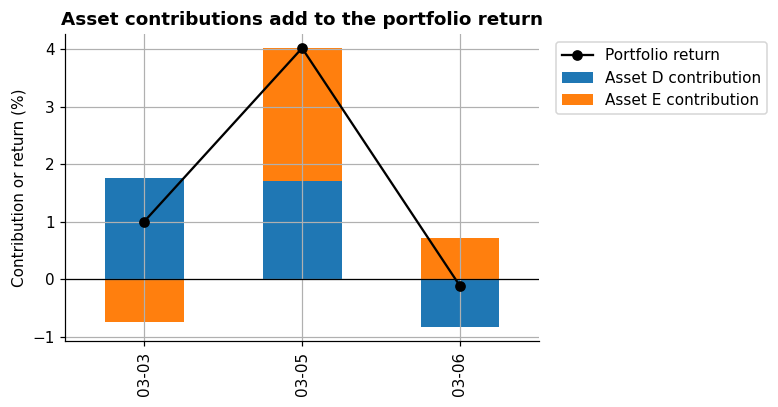

Hand portfolio return ending March 5: 0.0401500938086304


In [21]:
weights = pd.Series({"Asset_D": 0.70, "Asset_E": 0.30}, name="Starting_Weight")

if not np.isfinite(weights).all():
    raise ValueError("Weights must be finite.")
if not np.isclose(weights.sum(), 1.0):
    raise ValueError("Weights must sum to one for this exercise.")
if set(weights.index) != set(common_returns.columns):
    raise ValueError("Weight labels must match the return columns.")

weights = weights.reindex(common_returns.columns)

portfolio_return = common_returns.mul(weights, axis=1).sum(
    axis=1,
    min_count=len(weights),
).rename("Portfolio_Return")

portfolio_table = common_returns.assign(Portfolio_Return=portfolio_return)
display(weights.to_frame())
display(portfolio_table.round(6))

return_contributions = common_returns.mul(weights, axis=1)
return_contributions.columns = [f"{column}_Contribution" for column in return_contributions.columns]
contribution_table = pd.concat([return_contributions, portfolio_return], axis=1)
display(contribution_table.round(6))

plot_contributions = 100 * return_contributions.dropna(how="any")
plot_portfolio_return = 100 * portfolio_return.loc[plot_contributions.index]
plot_contributions.index = plot_contributions.index.strftime("%m-%d")
plot_contributions.columns = ["Asset D contribution", "Asset E contribution"]
ax = plot_contributions.plot(kind="bar", stacked=True, color=["tab:blue", "tab:orange"])
ax.plot(
    np.arange(len(plot_contributions)),
    plot_portfolio_return.values,
    color="black",
    marker="o",
    linewidth=1.5,
    label="Portfolio return",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Contribution or return (%)")
ax.set_title("Asset contributions add to the portfolio return")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

march_5_hand = (
    0.70 * (84.0 / 82.0 - 1.0)
    + 0.30 * (42.0 / 39.0 - 1.0)
)
print("Hand portfolio return ending March 5:", march_5_hand)

assert pd.isna(portfolio_return.iloc[0])
assert np.isclose(portfolio_return.loc["2026-03-05"], march_5_hand)

### Interpret the output


The first portfolio return remains missing because there is no preceding common endpoint. The March 5 calculation uses the same March 3-to-March 5 interval for both assets and the stated 70/30 beginning weights. The contribution table and stacked bars show how the weighted asset contributions add to the black portfolio-return line.


### Discussion questions

1. At what time must the weights be known for the March 3-to-March 5 return?
2. Why must weights be aligned by asset label rather than only by column position?
3. How would leverage or a cash holding change the weight constraints?
4. Why does this calculation not tell us whether 70/30 is a good weighting method?

### Evidence to preserve

Save the weight checks, component returns with interval labels, hand substitution, Python result, and a statement separating arithmetic from weight selection.

### First diagnostic action

When a portfolio return is missing or incorrect, inspect interval alignment, weight labels, weight sum, missing components, and the exact hand calculation.

# Independent practice issues

The four exercises below use new values and variable names. Preserve your prediction before coding, the complete input, calculations, checks, revisions, and unresolved questions. Starter cells intentionally do not contain solutions.

## Practice issue 1 — Select fields across corporate actions

Case A changes from price 120 with one share to price 40 with three shares after an artificial three-for-one split. Case B changes from price 75 to 73 and pays an artificial cash distribution of 4.

Calculate raw price return and position-value return for Case A. Calculate price return and simplified holding-period return for Case B. Then list the real provider fields required and one possible double-counting error.

Discussion: Which return answers each question? Which assumptions are artificial? What evidence would identify the event time? When would an adjusted field make a manual correction unnecessary?

In [22]:
practice_1_inputs = pd.DataFrame(
    {
        "Case": ["A_before", "A_after", "B_before", "B_after"],
        "Price": [120.0, 40.0, 75.0, 73.0],
        "Shares": [1.0, 3.0, 1.0, 1.0],
        "Cash_distribution": [0.0, 0.0, 0.0, 4.0],
    }
).set_index("Case")

display(practice_1_inputs)
print("Create new variables for the four required returns and add explicit assertions.")

,Price,Shares,Cash_distribution
Case,,,
A_before,120.0,1.0,0.0
A_after,40.0,3.0,0.0
B_before,75.0,1.0,0.0
B_after,73.0,1.0,4.0


Create new variables for the four required returns and add explicit assertions.


## Practice issue 2 — Reconcile returns and terminal wealth

Use the five artificial prices below. Calculate simple and log returns, reconcile their identity, construct a wealth index, verify the endpoint price ratio, and compare arithmetic with geometric mean return.

Discussion: How many holding intervals exist? Which first value remains missing? Which identity detects an interval error? What claim remains unsupported even if every check passes?

In [23]:
practice_2_price = pd.Series(
    [100.0, 104.0, 101.0, 106.0, 103.0],
    index=pd.to_datetime(
        ["2026-02-02", "2026-02-03", "2026-02-04", "2026-02-05", "2026-02-06"]
    ),
    name="Practice_2_Price",
)

display(practice_2_price.to_frame())
print("Predict terminal wealth and the ordering of the two means before calculating.")

,Practice_2_Price
2026-02-02,100.0
2026-02-03,104.0
2026-02-04,101.0
2026-02-05,106.0
2026-02-06,103.0


Predict terminal wealth and the ordering of the two means before calculating.


## Practice issue 3 — Audit a damaged financial table

Audit the table below without repairing it. Check parsing, order, duplicates, missing prices, nonpositive prices, and absent time-zone metadata. For each failed check, state why it matters, evidence needed before repair, proposed action or pending decision, and effect on the retained sample.

Discussion: Which issue prevents return calculation first? Which rows need provider evidence? Why is deleting all failed rows not a neutral solution? What should remain visible after a repair?

In [24]:
practice_3_records = pd.DataFrame(
    [
        ["2026-03-02 16:00", 50.0, 2_000],
        ["2026-03-03 16:00", 51.0, 2_100],
        ["2026-03-03 16:00", 51.2, 2_100],
        ["2026-03-05 16:00", np.nan, 1_900],
        ["2026-03-04 16:00", 0.0, 2_200],
    ],
    columns=["Timestamp", "Analysis_Price", "Volume"],
)

display(practice_3_records)
print("Preserve this original table and create a separate Boolean audit table.")

,Timestamp,Analysis_Price,Volume
0,2026-03-02 16:00,50.0,2000
1,2026-03-03 16:00,51.0,2100
2,2026-03-03 16:00,51.2,2100
3,2026-03-05 16:00,NaN,1900
4,2026-03-04 16:00,0.0,2200


Preserve this original table and create a separate Boolean audit table.


## Practice issue 4 — Integrated financial-data and return case

This case brings together the Week 2 documentation, audit, return, time-alignment, and portfolio calculations. The inputs remain artificial. They do not describe real securities, a real venue, or a provider's actual field construction.

The source record states that the table contains artificial closing prices for two artificial common stocks in the same artificial currency. The dates are artificial session labels rather than timezone-aware timestamps. No split or cash distribution occurs in the displayed interval. Asset G has no observed price on May 4. Do not forward-fill that value.

### Part A — Document the inputs

1. Complete the data-processing record using only the facts supplied by the case.
2. Preserve the source, asset, venue, security-type, currency, field, unit, frequency, and redistribution entries.
3. Mark timezone and any unsupported provider detail as `pending`; do not infer a real exchange convention.
4. State why `Close` is the selected analysis field for this artificial question and why that decision cannot be transferred automatically to a real provider.

### Part B — Audit before calculating

5. Verify date parsing, ascending order, uniqueness, positive observed prices, matching asset labels, finite weights, and a fully invested 60/40 allocation.
6. Produce a missing-value table and preserve the original Asset G gap.
7. State what additional calendar evidence would be required before classifying a similar real-data gap.
8. Confirm that no manual split or dividend adjustment is applied under the stated artificial assumptions.

### Part C — Calculate and reconcile

9. Construct the common endpoint price table before calculating either asset return.
10. Label the start and end of every resulting common holding interval.
11. Calculate simple and log returns for both assets and reconcile them numerically.
12. Validate the weight labels, finiteness, nonnegativity, and sum before multiplying returns.
13. Calculate each asset's weighted contribution and the one-period portfolio return.
14. Independently verify the portfolio return ending May 7 by substituting prices and weights by hand.
15. Construct a portfolio wealth index beginning at one on the first common endpoint.

### Part D — Communicate the evidence

16. Produce an audit table, common-endpoint table, interval-and-return table, contribution table, and wealth table.
17. Produce one figure that keeps the missing observation visible and identifies the retained common endpoints.
18. Write one conclusion supported by the artificial calculation and one conclusion the case cannot support.

### Discussion questions

1. Which input decision has the greatest effect on the represented holding intervals?
2. Why would calculating each asset's daily return before alignment create an invalid comparison here?
3. Which passed checks establish arithmetic consistency, and which financial facts still require an external source?
4. What information would be required before changing the starting weights or treating this result as a trading strategy?

### Required evidence

Preserve the four input tables below, every audit result, explicit interval labels, return identities, hand calculation, portfolio contributions, wealth index, figure, assertions, unresolved entries, and conclusion boundary. A successful run demonstrates a reproducible artificial calculation; it does not establish predictability, profitability after costs, or future performance.

In [25]:
practice_4_source_record = pd.DataFrame(
    {
        "Recorded_value": [
            "instructor-created artificial case",
            "Week 2 Practice issue 4",
            "embedded fixed table",
            "instructor-created course example; current repository access is private",
            "artificial session labels",
            "one observation per artificial session",
            "no split or cash distribution in the displayed interval",
            "no real-market claim permitted",
        ]
    },
    index=[
        "Provider",
        "Dataset",
        "Location",
        "Redistribution",
        "Timestamp meaning",
        "Observation frequency",
        "Corporate actions and distributions",
        "Claim boundary",
    ],
)

practice_4_asset_master = pd.DataFrame(
    {
        "Asset": ["Asset_F", "Asset_G"],
        "Security_type": ["Artificial common stock", "Artificial common stock"],
        "Venue": ["Artificial venue", "Artificial venue"],
        "Currency": ["ACU", "ACU"],
        "Selected_field": ["Artificial closing price", "Artificial closing price"],
        "Unit": ["ACU per share", "ACU per share"],
    }
).set_index("Asset")

practice_4_prices = pd.DataFrame(
    {
        "Asset_F": [90.0, 92.0, 91.0, 95.0, 94.0],
        "Asset_G": [45.0, np.nan, 46.0, 48.0, 47.0],
    },
    index=pd.to_datetime(
        ["2026-05-01", "2026-05-04", "2026-05-05", "2026-05-07", "2026-05-08"]
    ),
)
practice_4_weights = pd.Series(
    {"Asset_F": 0.60, "Asset_G": 0.40},
    name="Starting_Weight",
)

practice_4_case_inventory = pd.DataFrame(
    {
        "Object": ["Source record", "Asset master", "Price table", "Starting weights"],
        "Rows": [
            len(practice_4_source_record),
            len(practice_4_asset_master),
            len(practice_4_prices),
            len(practice_4_weights),
        ],
        "First student action": [
            "Complete pending documentation",
            "Verify identity, field, currency, and unit",
            "Audit dates, missing values, and positive observed prices",
            "Verify labels, constraints, and decision timing",
        ],
    }
)

display(practice_4_source_record)
display(practice_4_asset_master)
display(practice_4_prices)
display(practice_4_weights.to_frame("Starting_Weight"))
display(practice_4_case_inventory)
print("Case inputs loaded. Preserve them before creating audit or calculation objects.")
print("First calculation rule: build common price endpoints before calculating asset returns.")

,Recorded_value
Provider,instructor-created artificial case
Dataset,Week 2 Practice issue 4
Location,embedded fixed table
Redistribution,instructor-created course example; current rep...
Timestamp meaning,artificial session labels
Observation frequency,one observation per artificial session
Corporate actions and distributions,no split or cash distribution in the displayed...
Claim boundary,no real-market claim permitted


,Security_type,Venue,Currency,Selected_field,Unit
Asset,,,,,
Asset_F,Artificial common stock,Artificial venue,ACU,Artificial closing price,ACU per share
Asset_G,Artificial common stock,Artificial venue,ACU,Artificial closing price,ACU per share


,Asset_F,Asset_G
2026-05-01,90.0,45.0
2026-05-04,92.0,NaN
2026-05-05,91.0,46.0
2026-05-07,95.0,48.0
2026-05-08,94.0,47.0


,Starting_Weight
Asset_F,0.6
Asset_G,0.4


,Object,Rows,First student action
0,Source record,8,Complete pending documentation
1,Asset master,2,"Verify identity, field, currency, and unit"
2,Price table,5,"Audit dates, missing values, and positive obse..."
3,Starting weights,2,"Verify labels, constraints, and decision timing"


Case inputs loaded. Preserve them before creating audit or calculation objects.
First calculation rule: build common price endpoints before calculating asset returns.


# Terminology reference

Use these meanings when interpreting the Week 2 examples. For real data, provider definitions and the stated return convention remain authoritative.

| Term | Meaning used in Week 2 |
|---|---|
| price level | A price observation with an asset, time, field, currency, and unit |
| price return | Relative price change over a stated holding interval |
| holding-period return | Return over one stated interval, including the distributions explicitly included by its convention |
| simple return | $P_t/P_{t-1}-1$ for a consistently defined price series |
| log return | $\ln(P_t/P_{t-1})$ for positive prices |
| cumulative return | Compounded change across consecutive holding intervals |
| wealth index | Growth of one initial unit under the stated return sequence |
| arithmetic mean return | Sum of observed returns divided by their count |
| geometric mean return | Constant per-period return that reproduces the compounded terminal wealth |
| adjusted price | Provider-defined price series adjusted for specified events |
| total-return series | Provider-defined series that includes specified distributions under a stated convention |
| trading calendar | The sessions and special schedules defined for a particular market |
| observation frequency | Interval or sampling rule represented by consecutive observations |
| common holding interval | Shared start and end boundaries for returns being combined |
| portfolio return | Weighted sum of same-interval asset returns under stated weights |

# Troubleshooting reference

Use the first check before changing code or data. Preserve the failed output and document any later correction.

| Symptom | First check | Safe next action |
|---|---|---|
| `ModuleNotFoundError` | Read the missing package name | Install only the required package in the current environment, restart if needed, and rerun from the first cell |
| `ValueError` while creating a `DataFrame` | Compare values per record with the column count | Correct the source record before calculating |
| Date index remains `object` | Display `dtypes` and the parsing cell | Use `pd.to_datetime` with the expected format and `errors="raise"` |
| Duplicate timestamp | Display all rows sharing that timestamp and their identifiers | Preserve them and investigate the source key before selecting or removing a row |
| First return is `NaN` | Check whether an earlier price exists | Keep it missing in the return series |
| Zero return appears beside a missing price | Inspect fills before `pct_change` | Remove automatic filling and document the missing-value decision |
| Log return is infinite or missing unexpectedly | Display the two prices in the ratio | Stop on zero, negative, missing, or misaligned prices |
| Simple and log returns do not reconcile | Check order, alignment, and units | Recalculate both from the same two price observations |
| Wealth endpoint identity fails | Compare first price, last price, and included returns | Repair interval or compounding logic before interpreting the result |
| Weekly return differs from compounded daily return | List both weekly endpoints and included daily intervals | Align endpoints and use last observed analysis prices before calculating returns |
| Weekly OHLCV looks implausible | Inspect the aggregation used for each field | Use first, maximum, minimum, last, or sum only when it matches the field definition |
| A portfolio return appears on the first price date | Inspect component returns and `min_count` | Require every component return; do not treat missing as zero |
| Assets have different return horizons | Display start and end prices for each component | Align common price endpoints first and then recalculate returns |
| Return is 100 times too large | Inspect decimal-to-percent conversion | Convert to percent once, only for reporting |
| Assertion fails | Read the variables and rows used by that assertion | Preserve the failure and diagnose the data or formula; do not delete the assertion |

# Optional extensions and sources

## Optional extensions

These activities are not required for Week 2 completion:

- Add a third artificial asset in another currency and list the additional foreign-exchange information needed before forming one investor-currency portfolio return.
- Compare weekly OHLCV aggregation with an intentionally incorrect column-wise mean and explain every affected field.
- Introduce an extreme artificial return and prepare two competing explanations: a real event and a data or corporate-action error. State the evidence needed to distinguish them.
- Compare a price-only wealth index with a separately specified dividend-inclusive artificial return series without treating either as a provider's adjusted field.
- Create a normalized-price chart that starts each artificial asset at 1 and label the period, frequency, units, and artificial-data status.

## Official software references

- [`pandas.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) parses date-like values.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) calculates fractional change; its result is not automatically a percentage.
- [`pandas.DataFrame.resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) groups time-series observations by a stated frequency before an aggregation is applied.
- [pandas time-series documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html) documents time indexes, frequency conversion, and time-zone operations.
- [`numpy.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html), [`numpy.log1p`](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html), and [`numpy.expm1`](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html) support the log-return reconciliation used in the lesson.

## Financial and market references

- Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 1, “Prices, Returns, and Compounding,” pp. 9–13. [Publisher chapter record](https://doi.org/10.1515/9781400830213-005).
- The U.S. Securities and Exchange Commission's Investor.gov pages on [stock splits](https://www.investor.gov/introduction-investing/investing-basics/glossary/stock-split), [dividends](https://www.investor.gov/introduction-investing/investing-basics/glossary/dividend), and [investment returns](https://www.investor.gov/introduction-investing) support the basic split, distribution, and compound-growth distinctions used in the artificial examples.
- Nasdaq's [trading schedule](https://www.nasdaq.com/market-activity/stock-market-holiday-schedule) illustrates that a real market calendar includes holidays, special closes, session hours, and a stated time zone. It is not the calendar used by the artificial Week 2 dates.

The textbook supports standard return and compounding notation. Investor.gov supports the economic descriptions of splits and dividends. Nasdaq and pandas documentation support calendar and timestamp implementation examples. None defines the construction, correction history, or redistribution rights of a future course data provider; those items remain pending until the instructor approves a dataset.

# Completion evidence

## Required submission

Submit this completed notebook or an exported report containing:

1. the completed data-processing record in the preparation section of this notebook;
2. every worked-example cell with its visible audit output;
3. at least one written response selected from the discussion questions for each of Issues 1–20, plus any additional responses designated during class;
4. predictions, calculations, revisions, and preserved evidence for Practice issues 1–4;
5. a table listing unresolved provider, field, calendar, currency, or time-zone questions; and
6. one conclusion supported by the artificial evidence and one conclusion it cannot support.

## Completion conditions

The Week 2 work is complete when another student can:

- identify every required input, unit, timestamp meaning, and field definition;
- distinguish provider evidence from an access library and query specification;
- rerun every worked example without an execution error;
- reproduce return identities and hand calculations;
- explain every missing first return and every retained unresolved data problem;
- align multi-asset returns over common holding intervals;
- distinguish a fixed-weight arithmetic example from a method for selecting weights; and
- state why the notebook does not establish predictability, profitability, or future performance.

For the optional live yfinance example, submit the query record and diagnostic summary, not downloaded raw rows. The source record, field definitions, return calculations, date checks, and alignment evidence begin the data documentation required by the [Report 1 criteria](../10/week10_main.md). Week 2 does not change the report weights or add another grading criterion.

## Exit evidence

Complete these statements:

```text
The price or return field I used represents ______.
The most consequential data problem I checked was ______ because ______.
My multi-asset returns share the interval from ______ to ______.
The Week 2 evidence supports the conclusion that ______.
The Week 2 evidence does not support the conclusion that ______.
Before using real data, I still need provider evidence for ______.
```

A correct historical return describes the selected data, interval, and assumptions. It does not establish predictability, profitability after costs, or future investment performance.